<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_LinearVsNonLinear_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/08-email_classification_svm.csv')

In [23]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [25]:
df['email_type'].unique()

array([0, 1])

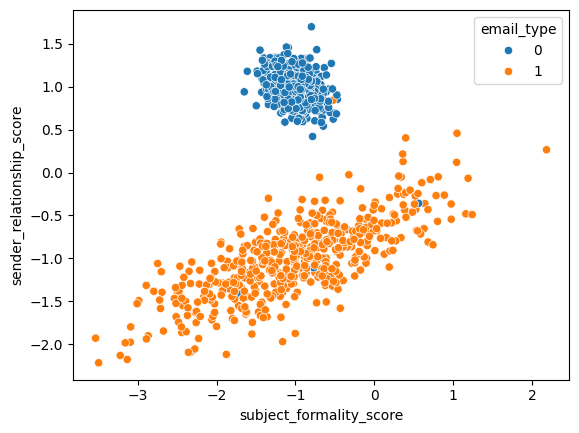

In [26]:
sns.scatterplot(x=df['subject_formality_score'],y=df['sender_relationship_score'],hue=df['email_type'])
plt.show()

In [27]:
X = df[['subject_formality_score','sender_relationship_score']].values
y = df['email_type'].values

In [28]:
y

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,

In [29]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]])

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [33]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [34]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

(torch.Size([800, 2]),
 torch.Size([800, 1]),
 torch.Size([200, 2]),
 torch.Size([200, 1]))

In [35]:
X_train.ndim

2

In [36]:
y_train.ndim

2

In [37]:
from torch import nn

In [72]:
# 2 katmanlı olacak şekilde ayarlıyoruz 5 nöron varmış gibi düşünelim
class ClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2,out_features=5)
    self.layer2 = nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer2(self.layer1(x))

In [73]:
model_0 = ClassificationModel()

In [74]:
# BCELoss içinde bir sigmoid hesabı yoktur
# BCEWithLogitLoss içinde sigmoid hesabı vardır
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [75]:
def calculate_accuracy(y_test,y_pred):
  correct = torch.eq(y_test,y_pred).sum().item() # 2 şey birbirine eşit mi diye hesaplayan fonksiyon eşitse 1 eşit değilse 0 tensör olarak döner
  accuracy = correct / len(y_pred) * 100
  return accuracy

In [76]:
y_logits = model_0(X_test)[:5]
y_logits

tensor([[-0.1342],
        [-0.2908],
        [-0.1631],
        [-0.2298],
        [-0.1364]], grad_fn=<SliceBackward0>)

In [77]:
y_pred_probs = torch.sigmoid(y_logits)

In [78]:
y_pred_probs

tensor([[0.4665],
        [0.4278],
        [0.4593],
        [0.4428],
        [0.4660]], grad_fn=<SigmoidBackward0>)

In [79]:
y_preds = torch.round(y_pred_probs)

In [80]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [81]:
calculate_accuracy(y_test[:5],y_preds)

60.0

In [82]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  acc = calculate_accuracy(y_test=y_train,y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # BCE Loss seçmiş olsaydık y_pred i vermiş olacaktık y_logitsi değil çünkü zaten BCELoss kendi kendine sigmoidi yapıyor
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = calculate_accuracy(y_test=y_test,y_pred=test_pred)

    if epoch % 5 == 0:
      print(f"Epoch : {epoch}, Loss : {loss} , Accuracy : {acc} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Epoch : 0, Loss : 0.723492443561554 , Accuracy : 49.75 , Test Loss : 0.7176529765129089 , Test Accuracy : 52.0
Epoch : 5, Loss : 0.7069980502128601 , Accuracy : 49.75 , Test Loss : 0.7006773352622986 , Test Accuracy : 52.0
Epoch : 10, Loss : 0.6911811232566833 , Accuracy : 49.75 , Test Loss : 0.6843975186347961 , Test Accuracy : 52.0
Epoch : 15, Loss : 0.6759693622589111 , Accuracy : 49.75 , Test Loss : 0.6687402129173279 , Test Accuracy : 52.0
Epoch : 20, Loss : 0.6612995266914368 , Accuracy : 49.75 , Test Loss : 0.6536413431167603 , Test Accuracy : 52.0
Epoch : 25, Loss : 0.6471153497695923 , Accuracy : 49.75 , Test Loss : 0.6390445232391357 , Test Accuracy : 52.0
Epoch : 30, Loss : 0.6333684921264648 , Accuracy : 50.125 , Test Loss : 0.6249003410339355 , Test Accuracy : 52.0
Epoch : 35, Loss : 0.6200160384178162 , Accuracy : 52.625 , Test Loss : 0.6111659407615662 , Test Accuracy : 54.0
Epoch : 40, Loss : 0.6070208549499512 , Accuracy : 58.62500000000001 , Test Loss : 0.597803831100